<a href="https://colab.research.google.com/github/juhee0528-lang/git/blob/main/lending_club_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주요 컬럼

*   종속변수: **default**
*   대출 이자율: **int_rate**
*   국채 수익률: **treasury_yield**
*   이자율과 국채 수익률은 **6.24**, **1.01**처럼 퍼센트 단위이므로 계산할 때 **/ 100**을 적용
*   원-핫 인코딩된 컬럼은 **bool형**이므로 **0/1**로 변환

In [8]:
# ============================================================
# 0. 라이브러리 불러오기
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report
)

from lightgbm import LGBMClassifier

In [10]:
# ============================================================
# 1. 데이터 불러오기
# ============================================================

train_path = "train.csv"
val_path = "validation.csv"

# 로컬/Jupyter 환경이라면 경로를 다음처럼 변경할 수 있습니다.
# train_path = "train(1).csv"
# val_path = "validation(1).csv"

train = pd.read_csv(train_path)
val = pd.read_csv(val_path)

print("Train 크기:", train.shape)
print("Validation 크기:", val.shape)

print("\nTrain 컬럼 수:", len(train.columns))
print("Validation 컬럼 수:", len(val.columns))

Train 크기: (310778, 66)
Validation 크기: (268623, 66)

Train 컬럼 수: 66
Validation 컬럼 수: 66


In [11]:
# ============================================================
# 2. 필수 컬럼 확인
# ============================================================

TARGET = "default"
INTEREST_COL = "int_rate"
TREASURY_COL = "treasury_yield"

required_columns = [
    TARGET,
    INTEREST_COL,
    TREASURY_COL
]

for col in required_columns:
    if col not in train.columns:
        raise ValueError(f"Train 데이터에 {col} 컬럼이 없습니다.")

    if col not in val.columns:
        raise ValueError(f"Validation 데이터에 {col} 컬럼이 없습니다.")


print("필수 컬럼 확인 완료")
print("종속변수:", TARGET)
print("이자율 컬럼:", INTEREST_COL)
print("국채수익률 컬럼:", TREASURY_COL)

필수 컬럼 확인 완료
종속변수: default
이자율 컬럼: int_rate
국채수익률 컬럼: treasury_yield


무한대 값을 결측값으로 변환

In [12]:
# ============================================================
# 3. inf, -inf 처리
# ============================================================

train = train.replace([np.inf, -np.inf], np.nan)
val = val.replace([np.inf, -np.inf], np.nan)

bool 컬럼을 0과 1로 변환

In [13]:
# ============================================================
# 4. bool 컬럼을 int8로 변환
# ============================================================

bool_cols = train.select_dtypes(include=["bool"]).columns.tolist()

print("bool 컬럼 수:", len(bool_cols))
print("bool 컬럼 목록:")
print(bool_cols)


for col in bool_cols:
    train[col] = train[col].astype("int8")

    if col in val.columns:
        val[col] = val[col].astype("int8")


print("\nbool 변환 완료")
print(train[bool_cols].dtypes)

bool 컬럼 수: 11
bool 컬럼 목록:
['home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'verification_status_Not Verified', 'verification_status_Source Verified', 'verification_status_Verified', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_other']

bool 변환 완료
home_ownership_MORTGAGE                int8
home_ownership_OTHER                   int8
home_ownership_OWN                     int8
home_ownership_RENT                    int8
verification_status_Not Verified       int8
verification_status_Source Verified    int8
verification_status_Verified           int8
purpose_credit_card                    int8
purpose_debt_consolidation             int8
purpose_home_improvement               int8
purpose_other                          int8
dtype: object


In [14]:
# ============================================================
# 5. 독립변수와 종속변수 분리
# ============================================================

X_train = train.drop(columns=[TARGET]).copy()
y_train = train[TARGET].astype(int).copy()

X_val = val.drop(columns=[TARGET]).copy()
y_val = val[TARGET].astype(int).copy()


# Validation 컬럼을 Train 컬럼과 동일하게 정렬
X_val = X_val.reindex(columns=X_train.columns)


print("X_train 크기:", X_train.shape)
print("X_val 크기:", X_val.shape)

print("\ny_train 클래스 분포:")
print(y_train.value_counts())

print("\ny_train 클래스 비율:")
print(y_train.value_counts(normalize=True).round(4))

X_train 크기: (310778, 65)
X_val 크기: (268623, 65)

y_train 클래스 분포:
default
0    155389
1    155389
Name: count, dtype: int64

y_train 클래스 비율:
default
0    0.5
1    0.5
Name: proportion, dtype: float64


원-핫 인코딩까지 되어 있으므로 모든 컬럼이 숫자형이어야 함

In [15]:
# ============================================================
# 6. 전체 독립변수를 숫자형으로 변환
# ============================================================

for col in X_train.columns:
    X_train[col] = pd.to_numeric(
        X_train[col],
        errors="coerce"
    )

    X_val[col] = pd.to_numeric(
        X_val[col],
        errors="coerce"
    )


print("Train 비숫자형 컬럼:")
print(
    X_train.select_dtypes(
        exclude=[np.number]
    ).columns.tolist()
)

print("\nValidation 비숫자형 컬럼:")
print(
    X_val.select_dtypes(
        exclude=[np.number]
    ).columns.tolist()
)

Train 비숫자형 컬럼:
[]

Validation 비숫자형 컬럼:
[]


In [16]:
# ============================================================
# 7. 전처리 + LightGBM 파이프라인
# ============================================================

model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "classifier",
            LGBMClassifier(
                objective="binary",

                # 모델 복잡도
                n_estimators=500,
                learning_rate=0.03,
                num_leaves=31,
                max_depth=-1,

                # 과적합 방지
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=0.1,

                # 클래스 불균형 대응
                class_weight="balanced",

                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

In [17]:
# ============================================================
# 8. 모델 학습
# ============================================================

model.fit(
    X_train,
    y_train
)

print("모델 학습 완료")

모델 학습 완료


**predict_proba()[:, 1]** 은 각 대출이 부도날 확률



*   **pred_default_prob = 0.10**: 예상 부도확률 10%
*   **pred_default_prob = 0.30**: 예상 부도확률 30%
*   **pred_default_prob = 0.70**: 예상 부도확률 70%





In [18]:
# ============================================================
# 9. Validation default 확률 예측
# ============================================================

val_default_prob = model.predict_proba(X_val)[:, 1]

val_result = val.copy()

val_result["pred_default_prob"] = val_default_prob


print(
    val_result[
        [
            TARGET,
            INTEREST_COL,
            TREASURY_COL,
            "pred_default_prob"
        ]
    ].head()
)

   default  int_rate  treasury_yield  pred_default_prob
0        1     11.49        0.897619           0.453833
1        1     13.99        1.280455           0.598015
2        0     15.61        1.026364           0.515609
3        0     14.65        1.030000           0.465047
4        0     11.48        1.140000           0.435035


10번 모델이 부도 여부를 어느 정도 잘 예측하고 있는지를 보여주는 기본 성능 평가표이다.

In [30]:
# ============================================================
# 10. 기본 분류 성능 확인
# ============================================================

auc = roc_auc_score(
    y_val,
    val_default_prob
)

basic_pred = (
    val_default_prob >= 0.5
).astype(int)

accuracy = accuracy_score(
    y_val,
    basic_pred
)

print("Validation ROC-AUC:", round(auc, 4))
print("Validation Accuracy:", round(accuracy, 4))

print("\n분류 리포트")
print(
    classification_report(
        y_val,
        basic_pred,
        digits=4
    )
)

Validation ROC-AUC: 0.7242
Validation Accuracy: 0.6513

분류 리포트
              precision    recall  f1-score   support

           0     0.8941    0.6443    0.7489    216826
           1     0.3137    0.6806    0.4294     51797

    accuracy                         0.6513    268623
   macro avg     0.6039    0.6624    0.5892    268623
weighted avg     0.7822    0.6513    0.6873    268623



**1. ROC-AUC = 0.7242**

ROC-AUC는 모델이 **부도 대출(default=1)**과 **정상 상환 대출(default=0)**을 얼마나 잘 구분하는지를 나타내는 지표이다.

* 0.5 : 무작위 예측
* 0.6~0.7 : 보통
* **0.7~0.8 : 양호**
* 0.8 이상 : 매우 우수

현재 결과는

> ROC-AUC = 0.7242

이므로,

> **모델이 정상 대출과 부도 대출을 비교적 잘 구분하고 있다고 판단할 수 있다.**

---
**2. Accuracy = 65.13%**

Accuracy는

*전체 데이터 / 맞게 예측한 건수*
이다.

현재

> 65.13% 이다.

하지만 Lending Club 데이터는

* 정상 대출이 약 80%
* 부도 대출이 약 20%

정도로 **불균형 데이터(Imbalanced Data)** 이다.

따라서 Accuracy 하나만 보고 모델 성능을 판단하는 것은 적절하지 않다.

---
**3. Precision**

부도라고 예측한 것 중 실제로 부도인 비율이다.

**Precision = 0.3137**

즉, 모델이

> "이 대출은 부도날 것이다."

라고 예측한 대출의 약 **31.37%** 가 실제 부도였다.

---
**4. Recall**

실제 부도 대출 중 모델이 찾아낸 비율이다.

**Recall = 0.6806**

즉,실제 부도 대출의 약 **68.06%** 를 모델이 찾아냈다.

이는 비교적 높은 값이다.

---
**5. F1-score**

Precision과 Recall의 균형이다.

현재 F1 = 0.4294 이다.

Precision은 조금 낮지만 Recall이 높기 때문에

부도 대출을 놓치지 않는 방향으로 학습된 모델이라고 볼 수 있다.

In [20]:
# ============================================================
# 11. 대출 수익률과 국채 수익률 생성
# ============================================================

# 퍼센트 단위를 소수 단위로 변환
# 예: 11.49% → 0.1149

val_result["interest_return"] = (
    pd.to_numeric(
        val_result[INTEREST_COL],
        errors="coerce"
    ) / 100
)

val_result["treasury_return"] = (
    pd.to_numeric(
        val_result[TREASURY_COL],
        errors="coerce"
    ) / 100
)


# 부도 시 회수율 가정
# 0.0이면 부도 시 원금 전액 손실
RECOVERY_RATE = 0.0


# 실제 대출 투자수익률
val_result["realized_return"] = np.where(
    val_result[TARGET] == 0,

    # 정상 상환: 이자율만큼 수익
    val_result["interest_return"],

    # 부도: 원금 손실, 회수율만큼 회수
    -1 + RECOVERY_RATE
)


# 전체 데이터에서 수익률 관련 결측값 확인
print(
    val_result[
        [
            "interest_return",
            "treasury_return",
            "realized_return"
        ]
    ].isna().sum()
)

interest_return    0
treasury_return    0
realized_return    0
dtype: int64


## Sharpe Ratio 계산 기준

투자 대상은 다음 조건으로 선택

→ **예측 부도확률 < threshold**

예를 들어 threshold가 0.2라면?

→ **예측 부도확률이 20% 미만인 대출에 투자**

대출별 실제 수익률은 다음과 같이 계산

→ **정상 상환(default=0): 이자율 수익**

→ **부도(default=1): 원금 100% 손실**

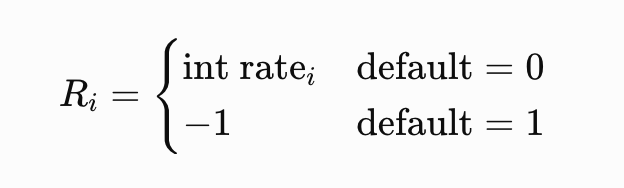

**초과수익률:**

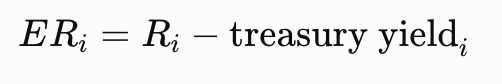


**Sharpe Ratio:**


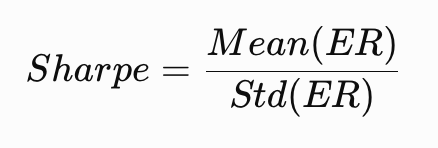

In [21]:
# ============================================================
# 12. Threshold별 Sharpe Ratio 계산 함수
# ============================================================

def calculate_sharpe_by_threshold(
    data,
    thresholds,
    min_investments=100,
    ddof=1
):
    """
    threshold별 투자 포트폴리오의 Sharpe Ratio를 계산합니다.

    Parameters
    ----------
    data : DataFrame
        pred_default_prob, realized_return,
        treasury_return 컬럼을 포함한 데이터

    thresholds : array-like
        적용할 default 확률 threshold 목록

    min_investments : int
        Sharpe Ratio를 계산하기 위한 최소 투자 건수

    ddof : int
        표준편차 자유도
        ddof=1은 표본 표준편차

    Returns
    -------
    DataFrame
        threshold별 투자 건수, 부도율, 수익률,
        초과수익률, 변동성, Sharpe Ratio
    """

    results = []

    for threshold in thresholds:

        # 예측 부도확률이 threshold보다 낮은 대출에 투자
        selected = data[
            data["pred_default_prob"] < threshold
        ].copy()

        investment_count = len(selected)

        # 투자 건수가 너무 적으면 결과 제외
        if investment_count < min_investments:
            results.append(
                {
                    "threshold": threshold,
                    "investment_count": investment_count,
                    "investment_ratio": investment_count / len(data),
                    "default_rate": np.nan,
                    "mean_loan_return": np.nan,
                    "mean_treasury_return": np.nan,
                    "mean_excess_return": np.nan,
                    "excess_return_std": np.nan,
                    "sharpe_ratio": np.nan
                }
            )

            continue


        # 대출별 초과수익률
        selected["excess_return"] = (
            selected["realized_return"]
            - selected["treasury_return"]
        )


        mean_excess_return = (
            selected["excess_return"].mean()
        )

        excess_return_std = (
            selected["excess_return"].std(ddof=ddof)
        )


        # 표준편차가 0이거나 결측값이면 Sharpe 계산 불가
        if (
            pd.isna(excess_return_std)
            or excess_return_std == 0
        ):
            sharpe_ratio = np.nan
        else:
            sharpe_ratio = (
                mean_excess_return
                / excess_return_std
            )


        results.append(
            {
                "threshold": threshold,

                "investment_count":
                    investment_count,

                "investment_ratio":
                    investment_count / len(data),

                "default_rate":
                    selected[TARGET].mean(),

                "mean_loan_return":
                    selected["realized_return"].mean(),

                "mean_treasury_return":
                    selected["treasury_return"].mean(),

                "mean_excess_return":
                    mean_excess_return,

                "excess_return_std":
                    excess_return_std,

                "sharpe_ratio":
                    sharpe_ratio
            }
        )


    return pd.DataFrame(results)

In [22]:
# ============================================================
# 13. Threshold 탐색
# ============================================================

thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

sharpe_results = calculate_sharpe_by_threshold(
    data=val_result,
    thresholds=thresholds,
    min_investments=100
)

sharpe_results.head(10)

,threshold,investment_count,investment_ratio,default_rate,mean_loan_return,mean_treasury_return,mean_excess_return,excess_return_std,sharpe_ratio
0,0.01,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,0.02,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,0.03,2,0.000007,NaN,NaN,NaN,NaN,NaN,NaN
3,0.04,45,0.000168,NaN,NaN,NaN,NaN,NaN,NaN
4,0.05,293,0.001091,0.003413,0.051954,0.011408,0.040546,0.062498,0.648754
5,0.06,951,0.003540,0.009464,0.046276,0.011413,0.034863,0.102443,0.340311
6,0.07,1911,0.007114,0.012559,0.043730,0.011657,0.032073,0.117838,0.272184
7,0.08,3162,0.011771,0.013283,0.043694,0.011818,0.031876,0.121224,0.262950
8,0.09,4592,0.017095,0.015026,0.042625,0.011927,0.030698,0.128931,0.238097
9,0.10,6123,0.022794,0.016495,0.041813,0.011927,0.029886,0.135099,0.221215


In [23]:
# ============================================================
# 14. Sharpe Ratio가 가장 높은 Threshold
# ============================================================

valid_results = sharpe_results.dropna(
    subset=["sharpe_ratio"]
).copy()


if len(valid_results) == 0:
    raise ValueError(
        "Sharpe Ratio를 계산할 수 있는 threshold가 없습니다."
    )


best_index = (
    valid_results["sharpe_ratio"].idxmax()
)

best_result = valid_results.loc[best_index]


print("=" * 50)
print("최적 투자 Threshold")
print("=" * 50)

print(
    "Best Threshold:",
    round(best_result["threshold"], 4)
)

print(
    "Best Sharpe Ratio:",
    round(best_result["sharpe_ratio"], 4)
)

print(
    "투자 건수:",
    int(best_result["investment_count"])
)

print(
    "전체 대출 중 투자 비율:",
    f"{best_result['investment_ratio'] * 100:.2f}%"
)

print(
    "선택된 대출의 실제 부도율:",
    f"{best_result['default_rate'] * 100:.2f}%"
)

print(
    "평균 대출 수익률:",
    f"{best_result['mean_loan_return'] * 100:.2f}%"
)

print(
    "평균 국채 수익률:",
    f"{best_result['mean_treasury_return'] * 100:.2f}%"
)

print(
    "평균 초과수익률:",
    f"{best_result['mean_excess_return'] * 100:.2f}%"
)

print(
    "초과수익률 표준편차:",
    f"{best_result['excess_return_std'] * 100:.2f}%"
)

최적 투자 Threshold
Best Threshold: 0.05
Best Sharpe Ratio: 0.6488
투자 건수: 293
전체 대출 중 투자 비율: 0.11%
선택된 대출의 실제 부도율: 0.34%
평균 대출 수익률: 5.20%
평균 국채 수익률: 1.14%
평균 초과수익률: 4.05%
초과수익률 표준편차: 6.25%


15번 그래프는 **Validation 데이터에서 threshold를 변화시키면서 어떤 threshold가 가장 높은 Sharpe Ratio를 만드는지**를 보여주는 그래프이다.

## **그래프 구성**

**x축 (Default probability threshold)**

모델이 예측한 **부도확률의 기준값(threshold)** 이다.


  예를 들어,


*   **Threshold = 0.05** : 예측 부도확률이 5% 미만인 대출만 투자
*   **Threshold = 0.20** : 예측 부도확률이 20% 미만인 대출에 투자
*   **Threshold = 0.80** : 거의 대부분의 대출에 투자


즉, ***오른쪽으로 갈수록 투자 대상이 많아진다.***

---
**y축 (Sharpe Ratio)**

*Sharpe Ratio = 초과수익률의 표준편차 / 평균 초과수익률*

값이 클수록
* 수익은 높고
* 위험은 낮은

좋은 투자 전략이라는 의미이다.

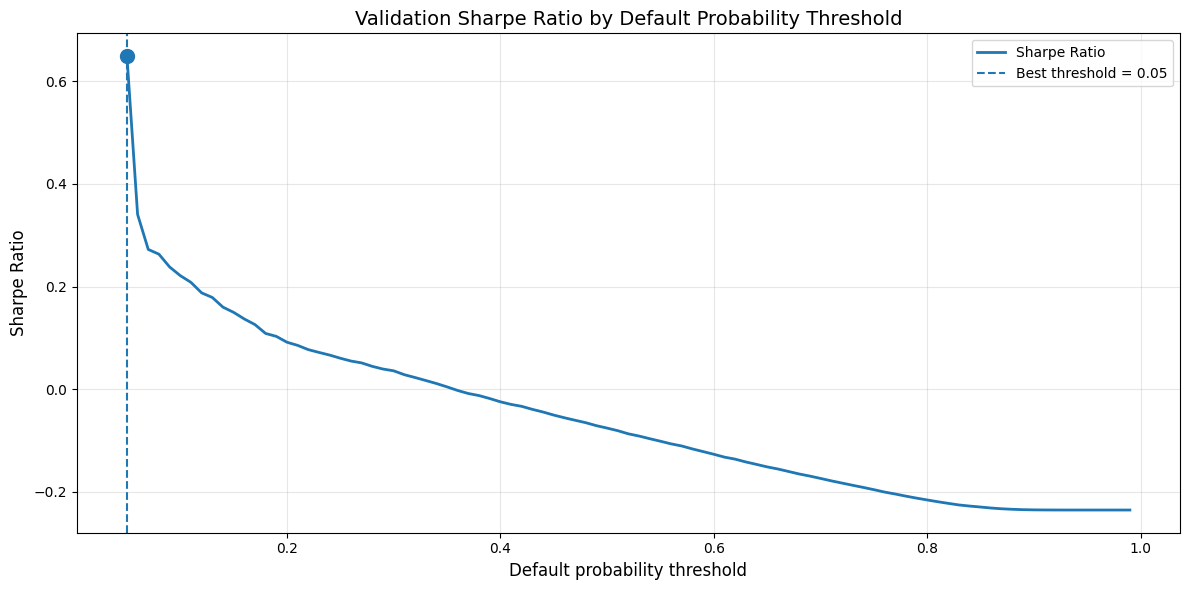

In [24]:
# ============================================================
# 15. Threshold별 Sharpe Ratio 그래프
# ============================================================

best_threshold = best_result["threshold"]
best_sharpe = best_result["sharpe_ratio"]


plt.figure(figsize=(12, 6))

plt.plot(
    sharpe_results["threshold"],
    sharpe_results["sharpe_ratio"],
    linewidth=2,
    label="Sharpe Ratio"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.scatter(
    best_threshold,
    best_sharpe,
    s=100,
    zorder=5
)

plt.xlabel(
    "Default probability threshold",
    fontsize=12
)

plt.ylabel(
    "Sharpe Ratio",
    fontsize=12
)

plt.title(
    "Validation Sharpe Ratio by Default Probability Threshold",
    fontsize=14
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

## **그래프 해석**

**① Threshold = 0.05에서 최고 Sharpe Ratio**

그래프에서 가장 높은 점은

> **Threshold = 0.05** 이며,

Sharpe Ratio가 약

> **0.65** 이다.

이는

> 모델이 **부도확률이 5%보다 낮다고 판단한 대출만 투자하는 것이 가장 좋은 성과**를 냈다는 뜻이다.

즉, 매우 안전한 대출만 선택했을 때

*   평균수익률은 높고
*   변동성은 낮아

Sharpe Ratio가 가장 크게 나타났다.

---
**② Threshold가 커질수록 Sharpe Ratio 감소**

Threshold를

**0.05 → 0.10 → 0.20 → 0.40 → 0.80**

으로 높이면 투자하는 대출 수가 증가한다.

하지만, 부도 가능성이 높은 대출도 함께 투자하게 되어

* 손실 증가
* 변동성 증가

하게 된다.

그래서 Sharpe Ratio가 계속 감소한다.

---
**③ Threshold 약 0.35부터 Sharpe Ratio가 음수**

그래프를 보면 약 **Threshold ≈ 0.35** 부터

Sharpe Ratio가 0보다 작아진다.

이는 **평균 초과수익률<0** 이라는 의미이다.

즉, 투자했더니 국채보다도 못한 성과를 냈다는 뜻이다.

---
**④ Threshold가 1에 가까워질수록**

Threshold가 **0.9 또는 1.0** 이면

거의 모든 대출에 투자한다.

그러면 부실대출까지 모두 투자하므로

* 손실 증가
* 평균 초과수익률 감소

결국 Sharpe Ratio가 약 -0.23까지 떨어진다.

이는
> **모든 대출에 무작정 투자하는 전략보다, 모델을 이용해 선별 투자하는 것이 훨씬 우수함**을 보여준다.




16번 그래프는 **threshold를 변화시킬 때 투자 대상으로 선택되는 대출의 개수**가 어떻게 변하는지를 보여준다.

## **그래프 구성**

**x축 (Default probability threshold)**

모델이 예측한 **부도확률의 기준값(threshold)** 입니다.

예를 들어,

*   **Threshold = 0.05** : 부도확률이 5% 미만인 대출만 투자
*   **Threshold = 0.20** : 부도확률이 20% 미만인 대출에 투자
*   **Threshold = 0.80** : 부도확률이 80% 미만인 대부분의 대출에 투자

즉, **threshold가 커질수록 투자 대상이 확대**된다.

---
**y축 (Number of selected loans)**

해당 threshold에서 **실제로 투자 대상으로 선택된 대출의 개수**를 의미한다.

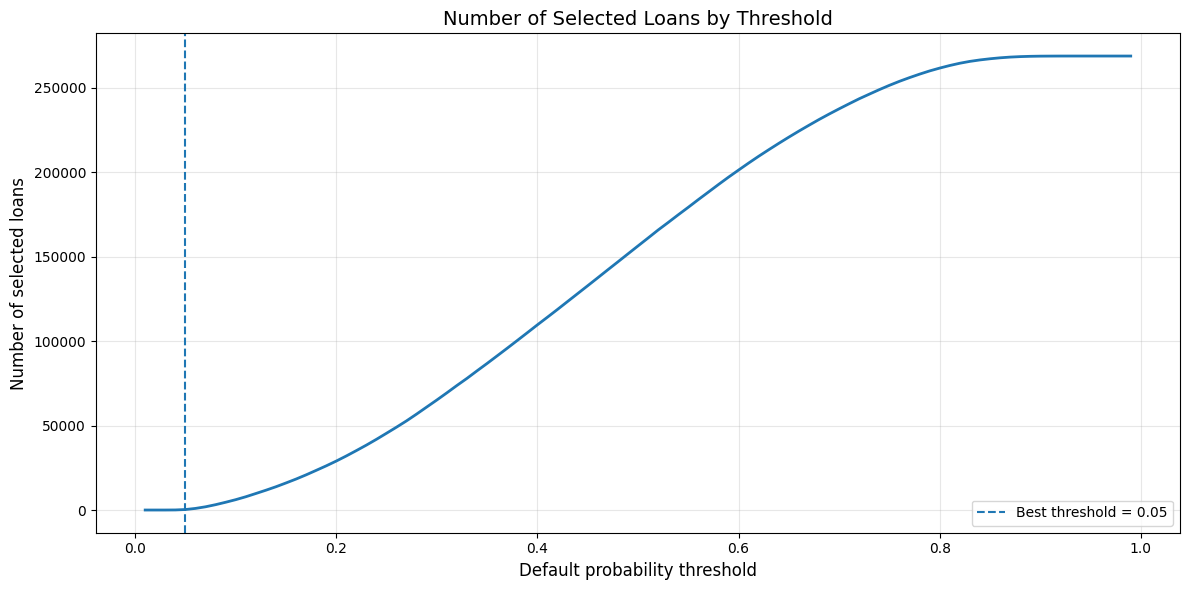

In [25]:
# ============================================================
# 16. Threshold별 투자 건수 그래프
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    sharpe_results["threshold"],
    sharpe_results["investment_count"],
    linewidth=2
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel(
    "Default probability threshold",
    fontsize=12
)

plt.ylabel(
    "Number of selected loans",
    fontsize=12
)

plt.title(
    "Number of Selected Loans by Threshold",
    fontsize=14
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

## **그래프 해석**

**① Threshold가 낮을수록 투자 대상이 매우 적다.**

그래프를 보면 **Threshold = 0.05**에서는 선택되는 대출 수가 매우 적다.

이는 모델이 **부도확률이 5% 미만이라고 매우 확신하는 대출만 선별**하기 때문이다.

즉,

* 매우 엄격한 투자 기준
* 가장 안전한 대출만 선택

이라는 의미이다.

---
**② Threshold가 증가할수록 투자 대상이 빠르게 증가한다.**

Threshold를 높이면

**0.05 → 0.20 → 0.40 → 0.60 → 0.80**

모델이 허용하는 위험 수준이 높아지므로

* 투자 가능한 대출 수가 계속 증가한다.

예를 들어

* Threshold 0.4에서는 약 10만 건 이상
* Threshold 0.6에서는 약 20만 건
* Threshold 0.8에서는 약 26만 건 이상

대출이 선택된다.

즉,
> 위험을 더 많이 허용할수록 더 많은 대출에 투자하게 된다.

---
**③ Threshold가 0.9 이상에서는 거의 모든 대출이 선택된다.**

Threshold가 1에 가까워질수록 거의 모든 대출의 부도확률이 기준보다 낮기 때문에
투자 대상 수가 전체 Validation 데이터의 개수와 거의 동일해진다.

그래프가 마지막에 평평해지는 이유도
더 이상 추가로 선택할 대출이 없기 때문이다.


17번 그래프는 **threshold에 따라 선택된 대출들의 실제 부도율(Actual Default Rate)** 이 어떻게 변하는지를 보여준다.

## **그래프 구성**

**x축 (Default probability threshold)**

모델이 예측한 **부도확률의 기준값(threshold)** 이다.

* **Threshold = 0.05** → 부도확률이 5% 미만인 대출만 투자
* **Threshold = 0.20** → 부도확률이 20% 미만인 대출에 투자
* **Threshold = 0.80** → 부도확률이 80% 미만인 대부분의 대출에 투자

Threshold가 커질수록 투자 대상이 많아진다.

---

**y축 (Actual default rate)**

선택된 대출들 중 **실제로 부도가 발생한 비율(%)** 이다.
즉, *Actual Default Rate = 선택된 대출 수 / 부도 대출 수 x 100* 이다.

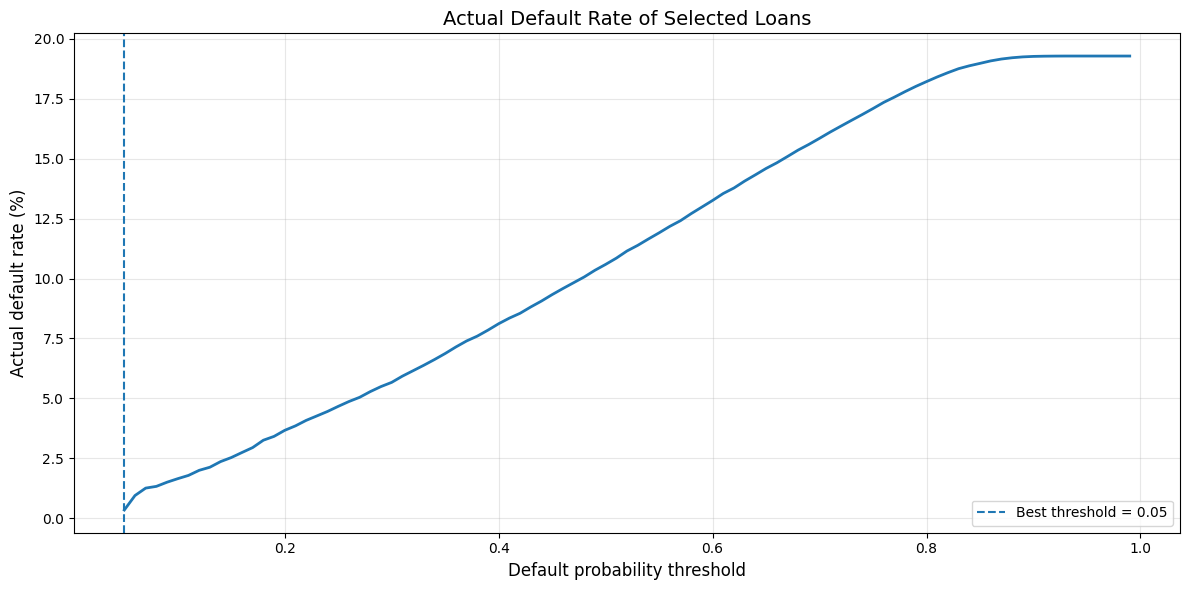

In [26]:
# ============================================================
# 17. Threshold별 실제 부도율 그래프
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    sharpe_results["threshold"],
    sharpe_results["default_rate"] * 100,
    linewidth=2
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel(
    "Default probability threshold",
    fontsize=12
)

plt.ylabel(
    "Actual default rate (%)",
    fontsize=12
)

plt.title(
    "Actual Default Rate of Selected Loans",
    fontsize=14
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()

## **그래프 해석**

**① Threshold = 0.05에서 실제 부도율이 가장 낮다.**

점선으로 표시된 최적 Threshold인 **0.05**에서는 실제 부도율이 약 **1% 내외**로 매우 낮다.

이는 모델이 부도확률이 낮다고 예측한 대출들이 실제로도 대부분 정상 상환되었다는 것을 의미한다.

즉, 모델이 **우량 대출을 효과적으로 선별**하고 있음을 보여준다.

---
**② Threshold가 증가할수록 실제 부도율이 꾸준히 증가한다.**

Threshold를 높이면

* 더 많은 대출을 투자 대상으로 선택하게 되고,
* 상대적으로 부도 가능성이 높은 대출도 함께 포함된다.

그 결과 실제 부도율이 점진적으로 증가한다.

예를 들어,

* Threshold가 약 **0.4**일 때는 실제 부도율이 약 **8%**
* Threshold가 약 **0.6**일 때는 약 **13%**
* Threshold가 **0.8 이상**이면 약 **18~19%** 까지 증가한다.

즉, **위험 허용 범위를 넓힐수록 실제 손실 위험도 함께 증가**하는 것을 확인할 수 있다.

---
**③ Threshold가 0.9 이상에서는 부도율이 거의 일정해진다.**

Threshold가 0.9를 넘으면 거의 모든 대출이 선택되므로, 추가로 포함되는 대출이 많지 않다.

따라서 실제 부도율도 약 **19% 수준에서 안정적으로 유지**된다.

이는 Validation 데이터 전체의 평균 부도율과 거의 동일한 수준이라고 해석할 수 있다.


In [27]:
# ============================================================
# 18. Sharpe Ratio 상위 10개 결과
# ============================================================

top_10_thresholds = (
    sharpe_results
    .dropna(subset=["sharpe_ratio"])
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)


display_columns = [
    "threshold",
    "sharpe_ratio",
    "investment_count",
    "investment_ratio",
    "default_rate",
    "mean_loan_return",
    "mean_treasury_return",
    "mean_excess_return",
    "excess_return_std"
]

top_10_thresholds[display_columns]

,threshold,sharpe_ratio,investment_count,investment_ratio,default_rate,mean_loan_return,mean_treasury_return,mean_excess_return,excess_return_std
4,0.05,0.648754,293,0.001091,0.003413,0.051954,0.011408,0.040546,0.062498
5,0.06,0.340311,951,0.003540,0.009464,0.046276,0.011413,0.034863,0.102443
6,0.07,0.272184,1911,0.007114,0.012559,0.043730,0.011657,0.032073,0.117838
7,0.08,0.262950,3162,0.011771,0.013283,0.043694,0.011818,0.031876,0.121224
8,0.09,0.238097,4592,0.017095,0.015026,0.042625,0.011927,0.030698,0.128931
9,0.10,0.221215,6123,0.022794,0.016495,0.041813,0.011927,0.029886,0.135099
10,0.11,0.208093,7842,0.029193,0.017853,0.041193,0.011935,0.029257,0.140598
11,0.12,0.187653,9763,0.036345,0.019973,0.039871,0.011960,0.027911,0.148738
12,0.13,0.178709,11708,0.043585,0.021268,0.039400,0.011964,0.027436,0.153524
13,0.14,0.159861,13764,0.051239,0.023612,0.037804,0.011951,0.025853,0.161719


In [28]:
top_10_display = top_10_thresholds.copy()

percent_columns = [
    "investment_ratio",
    "default_rate",
    "mean_loan_return",
    "mean_treasury_return",
    "mean_excess_return",
    "excess_return_std"
]

for col in percent_columns:
    top_10_display[col] = (
        top_10_display[col] * 100
    ).round(2)

top_10_display["sharpe_ratio"] = (
    top_10_display["sharpe_ratio"].round(4)
)

top_10_display["threshold"] = (
    top_10_display["threshold"].round(2)
)

top_10_display

,threshold,investment_count,investment_ratio,default_rate,mean_loan_return,mean_treasury_return,mean_excess_return,excess_return_std,sharpe_ratio
4,0.05,293,0.11,0.34,5.20,1.14,4.05,6.25,0.6488
5,0.06,951,0.35,0.95,4.63,1.14,3.49,10.24,0.3403
6,0.07,1911,0.71,1.26,4.37,1.17,3.21,11.78,0.2722
7,0.08,3162,1.18,1.33,4.37,1.18,3.19,12.12,0.2630
8,0.09,4592,1.71,1.50,4.26,1.19,3.07,12.89,0.2381
9,0.10,6123,2.28,1.65,4.18,1.19,2.99,13.51,0.2212
10,0.11,7842,2.92,1.79,4.12,1.19,2.93,14.06,0.2081
11,0.12,9763,3.63,2.00,3.99,1.20,2.79,14.87,0.1877
12,0.13,11708,4.36,2.13,3.94,1.20,2.74,15.35,0.1787
13,0.14,13764,5.12,2.36,3.78,1.20,2.59,16.17,0.1599


In [29]:
# ============================================================
# 19. 최적 Threshold 기준 투자 대상 추출
# ============================================================

best_portfolio = val_result[
    val_result["pred_default_prob"]
    < best_threshold
].copy()


best_portfolio["excess_return"] = (
    best_portfolio["realized_return"]
    - best_portfolio["treasury_return"]
)


print("최적 포트폴리오 대출 수:", len(best_portfolio))

print(
    "최적 포트폴리오 부도율:",
    f"{best_portfolio[TARGET].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 평균 초과수익률:",
    f"{best_portfolio['excess_return'].mean() * 100:.2f}%"
)

print(
    "최적 포트폴리오 Sharpe Ratio:",
    round(
        best_portfolio["excess_return"].mean()
        / best_portfolio["excess_return"].std(ddof=1),
        4
    )
)

최적 포트폴리오 대출 수: 293
최적 포트폴리오 부도율: 0.34%
최적 포트폴리오 평균 초과수익률: 4.05%
최적 포트폴리오 Sharpe Ratio: 0.6488
